<font color="black"><font size="7"><br>
     Project 7 - preprocessing Pipeline
</font>

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import math

from sklearn.feature_extraction.text import CountVectorizer

from nltk.corpus import wordnet

import nltk

from nltk.stem.snowball import SnowballStemmer
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer

from gensim.models import doc2vec

from collections import defaultdict

# Loading data

In [190]:
data=pd.read_csv("D:/Data OC/P7/sentiment140/training.1600000.processed.noemoticon.csv",header=None,names=['target','text'],usecols=[0,5])

In [191]:
data.head()

,target,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


In [193]:
data['target'] = data['target']/4

In [195]:
data = data.astype({'target':'int32'},copy=False)

In [197]:
data.to_pickle('data/data')

In [2]:
data = pd.read_pickle('data/data')

In [3]:
#create a sample dataset for function testing
data_sample = data.sample(n=500)

# Tokenizer

In [4]:
data_sample.head()

,target,text
1570422,1,ahhhh..much better 4 all of u who dont exerci...
1288465,1,@jimnicebutdim now *that* is interesting. Also...
732980,0,http://twitpic.com/7zubz - the weather when i ...
1174526,1,@manic_nimrod Ryan Kelly.
207184,0,"when your up, why do people love to bring u do..."


In [6]:
def tokenizer(data):
    '''tokenizes input dataframe considering words of 2 and more characters
       and lowercase text and remove numbers
    
       Parameters
       ----------
       data : String chain to tokenize
       
       Returns
       --------
       data : Panda series list of tokens'''
              
        
    tokenizer = nltk.RegexpTokenizer(r'\w{2,}')
    sentences = data.str.lower()
    sentences = sentences.str.replace('\d+', '',regex=True)
    results = sentences.apply(tokenizer.tokenize)
  
    return results

In [7]:
data_sample['tokens']=tokenizer(data_sample['text'])

In [8]:
data_sample

,target,text,tokens
1570422,1,ahhhh..much better 4 all of u who dont exerci...,"[ahhhh, much, better, all, of, who, dont, exer..."
1288465,1,@jimnicebutdim now *that* is interesting. Also...,"[jimnicebutdim, now, that, is, interesting, al..."
732980,0,http://twitpic.com/7zubz - the weather when i ...,"[http, twitpic, com, zubz, the, weather, when,..."
1174526,1,@manic_nimrod Ryan Kelly.,"[manic_nimrod, ryan, kelly]"
207184,0,"when your up, why do people love to bring u do...","[when, your, up, why, do, people, love, to, br..."
...,...,...,...
1008918,1,"raining away in sydney, good nice 2 snuggle in...","[raining, away, in, sydney, good, nice, snuggl..."
177323,0,I wish Saturday Night Fever was on again! I co...,"[wish, saturday, night, fever, was, on, again,..."
892978,1,@xfftl8myheartx i noticed,"[xfftlmyheartx, noticed]"
421622,0,@JulieeM now i'm paranoid,"[julieem, now, paranoid]"


# Stemming

In [9]:
def stemmer(data,stemmer):
    ''' Stems data using stemmer returns stems as a listof strings'''


    def stem_sentence(tokenized_sentence):
        stems = [stemmer.stem(i) for i in tokenized_sentence]
        return stems
    
    return data.apply(stem_sentence)


In [10]:
data_sample['stems'] = stemmer(data_sample['tokens'],PorterStemmer())

# Lemmatization

In [11]:
def lemmatizer(data,lemmatizer):
    
    def get_wordnet_pos(word):
    #Map POS tag to first character lemmatize() accepts
        tag = nltk.pos_tag([word])[0][1][0].upper()
        tag_dict = {"J": wordnet.ADJ,
                    "N": wordnet.NOUN,
                    "V": wordnet.VERB,
                    "R": wordnet.ADV}
        return tag_dict.get(tag, wordnet.NOUN)


    def lem_sentence(tokenized_sentence):
        lems = [lemmatizer.lemmatize(i,pos=get_wordnet_pos(i)) for i in tokenized_sentence]
        return lems 

    
    return data.apply(lem_sentence)

In [12]:
data_sample['lems'] = lemmatizer(data_sample['tokens'],WordNetLemmatizer())

In [13]:
data_sample

,target,text,tokens,stems,lems
1570422,1,ahhhh..much better 4 all of u who dont exerci...,"[ahhhh, much, better, all, of, who, dont, exer...","[ahhhh, much, better, all, of, who, dont, exer...","[ahhhh, much, well, all, of, who, dont, exerci..."
1288465,1,@jimnicebutdim now *that* is interesting. Also...,"[jimnicebutdim, now, that, is, interesting, al...","[jimnicebutdim, now, that, is, interest, also,...","[jimnicebutdim, now, that, be, interest, also,..."
732980,0,http://twitpic.com/7zubz - the weather when i ...,"[http, twitpic, com, zubz, the, weather, when,...","[http, twitpic, com, zubz, the, weather, when,...","[http, twitpic, com, zubz, the, weather, when,..."
1174526,1,@manic_nimrod Ryan Kelly.,"[manic_nimrod, ryan, kelly]","[manic_nimrod, ryan, kelli]","[manic_nimrod, ryan, kelly]"
207184,0,"when your up, why do people love to bring u do...","[when, your, up, why, do, people, love, to, br...","[when, your, up, whi, do, peopl, love, to, bri...","[when, your, up, why, do, people, love, to, br..."
...,...,...,...,...,...
1008918,1,"raining away in sydney, good nice 2 snuggle in...","[raining, away, in, sydney, good, nice, snuggl...","[rain, away, in, sydney, good, nice, snuggl, i...","[rain, away, in, sydney, good, nice, snuggle, ..."
177323,0,I wish Saturday Night Fever was on again! I co...,"[wish, saturday, night, fever, was, on, again,...","[wish, saturday, night, fever, wa, on, again, ...","[wish, saturday, night, fever, be, on, again, ..."
892978,1,@xfftl8myheartx i noticed,"[xfftlmyheartx, noticed]","[xfftlmyheartx, notic]","[xfftlmyheartx, notice]"
421622,0,@JulieeM now i'm paranoid,"[julieem, now, paranoid]","[julieem, now, paranoid]","[julieem, now, paranoid]"


# removing stop words

In [156]:
def remove_stopwords(data, stopwords):
    '''Remove stopwords from data'''

    # remove stopwords from stems and create a new column
    results = [[stem for stem in stems if (
        not(stem in stopwords))] for stems in data]
    
    return results

In [159]:
stopwords = nltk.corpus.stopwords.words('english')

# Exploratory analysis

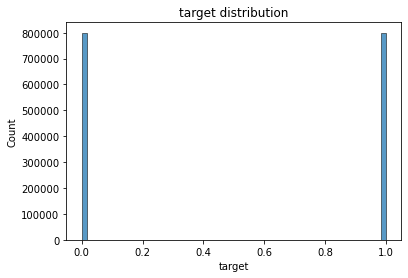

In [203]:
sns.histplot(data['target'])
plt.title('target distribution')
plt.show()

# Test Train Split

In [63]:
X = list(data_sample['stems'].values)

In [64]:
y = list(data_sample['target'].values)

In [66]:
from sklearn.model_selection import train_test_split

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=33,stratify=y)

# Doc2vec

In [57]:
model = doc2vec.Doc2Vec(vector_size=50, min_count=2, epochs=40)

In [70]:
train_corpus = []
#build the train corpus
for i,line in enumerate(X_train):
    train_corpus.append(doc2vec.TaggedDocument(line,i))

In [71]:
train_corpus

[TaggedDocument(words=['realli', 'need', 'some', 'bone', 'follow'], tags=0),
 TaggedDocument(words=['down', 'in', 'cleveland', 'with', 'marcu', 'and', 'kenni', 'volunt', 'at', 'the', 'west', 'side', 'cathol', 'center', 'feed', 'the', 'poor', 'pretti', 'fun', 'so', 'far'], tags=1),
 TaggedDocument(words=['grimesforev', 'sens', 'much', 'need', 'trip', 'to', 'dead', 'citi', 'we', 're', 'set', 'up', 'the', 'home', 'studio', 'thi', 'week', 'too', 'even', 'more', 'reason', 'to', 'join', 'us'], tags=2),
 TaggedDocument(words=['jonasbroth', 'ya', 'know', 'wat', 'learn', 'new', 'beat', 'in', 'drum', 'today', 'oh', 'ye', 'am', 'good', 'well', 'not', 'realli', 'but', 'that', 'an', 'accomplish', 'for', 'me'], tags=3),
 TaggedDocument(words=['brain', 'is', 'leak'], tags=4),
 TaggedDocument(words=['johnmetbetti', 'ye', 'if', 'you', 'want', 'great', 'exposur', 'it', 'could', 'be', 'veri', 'worthwhil'], tags=5),
 TaggedDocument(words=['watchin', 'the', 'mtv', 'movi', 'award', 'wait', 'for', 'eminem', 

In [73]:
model.build_vocab(documents=train_corpus)

TypeError: 'int' object is not iterable

In [24]:
model_w2v.build_vocab(list(data_sample['lems'].values))

In [25]:
print(model_w2v)

Word2Vec(vocab=1916, size=100, alpha=0.025)


In [26]:
model_w2v.wv.vocab

{'ahhhh': <gensim.models.keyedvectors.Vocab at 0x24914096490>,
 'much': <gensim.models.keyedvectors.Vocab at 0x24914096520>,
 'well': <gensim.models.keyedvectors.Vocab at 0x24914096580>,
 'all': <gensim.models.keyedvectors.Vocab at 0x249140965e0>,
 'of': <gensim.models.keyedvectors.Vocab at 0x24914096640>,
 'who': <gensim.models.keyedvectors.Vocab at 0x24914096670>,
 'dont': <gensim.models.keyedvectors.Vocab at 0x24914096730>,
 'exercise': <gensim.models.keyedvectors.Vocab at 0x24914096760>,
 'get': <gensim.models.keyedvectors.Vocab at 0x24914096790>,
 'move': <gensim.models.keyedvectors.Vocab at 0x24914096820>,
 'always': <gensim.models.keyedvectors.Vocab at 0x24914096880>,
 'feel': <gensim.models.keyedvectors.Vocab at 0x249140968e0>,
 'when': <gensim.models.keyedvectors.Vocab at 0x24914096940>,
 'it': <gensim.models.keyedvectors.Vocab at 0x24914096970>,
 'do': <gensim.models.keyedvectors.Vocab at 0x24914096a30>,
 'jimnicebutdim': <gensim.models.keyedvectors.Vocab at 0x24914096a60>,
 

In [40]:
model_w2v = Word2Vec('I like apples')

RuntimeError: you must first build vocabulary before training the model

In [45]:
model_w2v.vocabulary.sorted_vocab

True

In [51]:
model_w2v.vocabulary.raw_vocab

defaultdict(int, {})

In [31]:
model_w2v.most_similar(positive=['hello','sleep'],negative='good')

<ipython-input-31-c32f4483aba0>:1: DeprecationWarning: Call to deprecated `most_similar` (Method will be removed in 4.0.0, use self.wv.most_similar() instead).
  model_w2v.most_similar(positive=['hello','sleep'],negative='good')


KeyError: "word 'hello' not in vocabulary"